# Using Numerical Optimisation to predict Vanilla Tables

## Imports

In [221]:
import pickle
import random
import csv
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches
from math import pi, sqrt, e, log
import functions as func
from scipy.optimize import minimize, Bounds
from importlib import reload
from statistics import NormalDist
reload(func)

<module 'functions' from 'c:\\Users\\Mahfuzah Fariha\\PhD Repositories\\choice-of-reduction-functions\\cherry-picking-reduction-functions\\plots\\higher_costs\\N_16\\constructing_table\\functions.py'>

## Constants

In [222]:
N = 2 ** 16
p = 1-e**-2 # our table coverage

# keep track of number of reductions so can take that away from cost at the end
num_reductions = 0

## Numerical Optimisation

In [223]:
# Optimise 
# add vcost to bound the optimisation
def optimise_kj(N, p, alpha, factor, lower_bound):   # add v_cost if want vanilla cost to be set beforehand
    t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t
    mt_target = N**(2/3) # our target mt
    m_0 = round(mt_target/(1-alpha))    # our starting m_0
    
    ## set the bound and target function
    # TODO: change upper bound when needed
    bound = Bounds([lower_bound for i in range(t)], [1 for i in range(t)])
    
    # our target function that needs to be > 0
    # instead of using the target function, we can use the cost function as the objective function
    # need to get the cost of a vanilla rainbow table with the same parameters
    
    # Const * P(vanilla) - P(cherry) > 0
    v_cost, m = func.vanilla_cost(N, m_0, t)
    v_cost = v_cost * factor
    ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - func.cost(x, N, m_0)[0]}

    ## use 1 as starting values for cherry-picking
    starting_values = [1 for i in range(t)]
    
    ## call the optimizer
    # maximise the 
    # 5000000 normally
    res = minimize(lambda Kj: func.m_t(Kj, N, m_0), starting_values, bounds=bound, constraints=ineq_cons,method = "SLSQP", options={'disp': True, "maxiter": 5000000, "eps": 1, "ftol": 1})
    
    ## res.x is the result of the optimization
    final_cost, m_values = func.cost(res.x, N, m_0) # calculate the final cost and m values
    return res.x, m_0, final_cost, m_values

## Generate results

In [224]:
%%script false

result = optimise_kj(N, p, 0.95, 1, 1)
kjs, m_0, final_cost, m_values = result
# store in pickle file
with open("vanilla_N_16__alpha_0.95_sim_results.pkl", "wb") as f:
    pickle.dump(result, f)

print("your tag didn't work")

Couldn't find program: 'false'


In [225]:
%%script false

final_cost

Couldn't find program: 'false'


In [226]:
%%script false

func.vanilla_cost(N, m_0, round(log(1-p)/log(1-N**(-1/3))))

Couldn't find program: 'false'


In [227]:
%%script false

len(kjs)

Couldn't find program: 'false'


In [228]:
%%script false

# try and calculate the last m_t
m = m_values[-1]
vcost = final_cost


# Calculate E1 and E2
E1 = (1 - 1 / N) ** m
E2 = (1 - 2 / N) ** m
average = N * (1 - E1)

# check variance
if N * ((N - 1) * E2 + E1 - N * E1 ** 2) < 0:
    # if it is negative (error), set it to 0
    variance = 0
else:
    # count the variance otherwise
    variance = sqrt(N * ((N - 1) * E2 + E1 - N * E1 ** 2))

vcost =  vcost + m + 1 / 577.44 

# find the m_j+1
m = average + NormalDist().inv_cdf((1 - pi / 8) / (1 - pi / 4 + 1)) * variance

print(m)
print(vcost)

Couldn't find program: 'false'


## Try for N = 2**20

In [229]:
%%script false

N = 2 ** 20
Kis, m_0, final_cost, m_values = optimise_kj(N, p, 0.95, 1, 1)

# try and calculate the last m_t
m = m_values[-1]
vcost = final_cost


# Calculate E1 and E2
E1 = (1 - 1 / N) ** m
E2 = (1 - 2 / N) ** m
average = N * (1 - E1)

# check variance
if N * ((N - 1) * E2 + E1 - N * E1 ** 2) < 0:
    # if it is negative (error), set it to 0
    variance = 0
else:
    # count the variance otherwise
    variance = sqrt(N * ((N - 1) * E2 + E1 - N * E1 ** 2))

# add on the number of hashes done - no reductions as we are just doing mod which is already fast
vcost =  vcost + m + 1 / 577.44 

# find the m_j+1
m = average + NormalDist().inv_cdf((1 - pi / 8) / (1 - pi / 4 + 1)) * variance

# append the final column and replace final cost
m_values.append(m)
final_cost = vcost

print(m)
print(vcost)

Couldn't find program: 'false'


In [230]:
%%script false

# Build the table and see what the m_t value is
t = round(log(1-p)/log(1-N**(-1/3)))
# make startpoints
starpoints = set()
while len(starpoints) < (0.95*N):
    starpoints.add(random.randint(0, N-1))

table = func.build_vanilla_table(N, t, starpoints)

Couldn't find program: 'false'


In [231]:
%%script false

len(table)

Couldn't find program: 'false'


## Compare Different Vanilla Simulations with their Respective Actual Tables

- At different N
- At same N with different alpha (so different startpoints)

### At Same N with different alpha

In [232]:
# adjust the sumulated cost and m_t
def adjust_simulation(m_values, final_cost, N):
    # try and calculate the last m_t
    m = m_values[-1]
    vcost = final_cost

    # Calculate E1 and E2
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m
    average = N * (1 - E1)

    # check variance
    if N * ((N - 1) * E2 + E1 - N * E1 ** 2) < 0:
        # if it is negative (error), set it to 0
        variance = 0
    else:
        # count the variance otherwise
        variance = sqrt(N * ((N - 1) * E2 + E1 - N * E1 ** 2))

    # add on the number of hashes done - no reductions as we are just doing mod which is already fast
    vcost =  vcost + m + 1 / 577.44 

    # find the m_j+1
    m = average + NormalDist().inv_cdf((1 - pi / 8) / (1 - pi / 4 + 1)) * variance

    # return the adjusted values
    return m, vcost


In [233]:
%%script false

# for N = 2**16, t=80, but alpha between 0.5 and 0.95
N = 2 ** 16
t= t = round(log(1-p)/log(1-N**(-1/3)))
alphas = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
starpoint_sets = []
optimisation_results = []
optimisation_mt = []
generation_results = []
generation_mt = []
samples = 50

# for each alpha 
for alpha in alphas:
    # run the optimisation
    kis, m_0, final_cost, m_values = optimise_kj(N, p, alpha, 1, 1)
    # adjust the simulation results and store
    adjusted_m, adjusted_cost = adjust_simulation(m_values, final_cost, N)
    m_values.append(adjusted_m)
    result = [kis, m_0, adjusted_cost, m_values]
    optimisation_results.append(result)
    # store the simulated m_t
    optimisation_mt.append(adjusted_m)

    # build the actual table - 100 times 
    # first generate starpoints and store them
    vanilla_m_0 = round(N**(2/3)/(1-alpha))
    this_alpha_startpoints = []
    # generate 100 sets of starpoints
    for i in range(samples):
        starpoints = set()
        while len(starpoints) < (vanilla_m_0):
            starpoints.add(random.randint(0, N-1))

        this_alpha_startpoints.append(starpoints)
    # append to main list
    starpoint_sets.append(this_alpha_startpoints)

    # build the vanilla table 100 times and store it for later
    this_alpha_tables = []
    this_alpha_mt = []
    for i in range(samples):
        # get starpoints
        starpoints = this_alpha_startpoints[i]
        # make the table with these startpoints
        table = func.build_vanilla_table(N, t, starpoints)
        # append to this alpha's tables
        this_alpha_tables.append(table)
        this_alpha_mt.append(len(table))
    
    # append to main list
    generation_results.append(this_alpha_tables)
    generation_mt.append(this_alpha_mt)


Couldn't find program: 'false'


In [234]:
%%script false

# store in a csv file
with open("vanilla_N_16_different_alpha_results.csv", "w", newline='') as f:
    f_alpha = csv.writer(f) # create a csv writer

    # create a list of headers for the different trials
    trial_headers = []
    for i in range(samples):
        trial_headers.append(f"trial_{i+1}")
    
    f_alpha.writerow(["alpha", "optimiser_mt"] + trial_headers)

    # add in data for each alpha
    for i in range(len(alphas)):
        row = [alphas[i], optimisation_mt[i]] + generation_mt[i]
        f_alpha.writerow(row)

Couldn't find program: 'false'


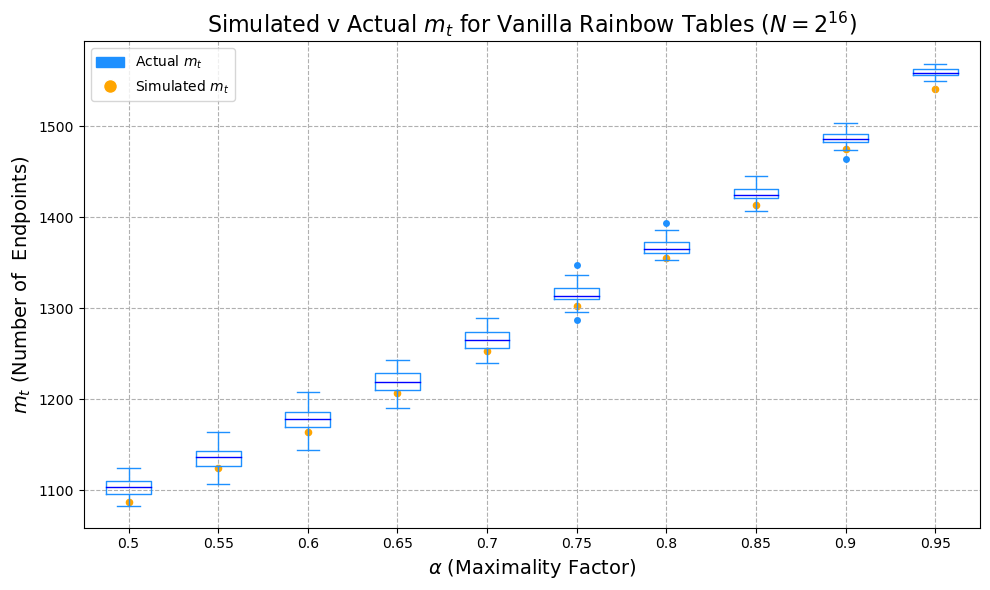

In [235]:
# Make into a graph
alphas = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

data = pd.read_csv("vanilla_N_16_different_alpha_results.csv")
x_indicies = range(len(alphas))

plt.figure(figsize=(10,6))

# plot for each alpha, a box plot using the trials
# convert samples from dataframe to a single list for boxplot
plt.boxplot([data.loc[data['alpha'] == alpha, data.columns[2:]].values.flatten() for alpha in alphas], 
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='dodgerblue'),
            medianprops=dict(color='blue'),
            whiskerprops=dict(color='dodgerblue'),
            capprops=dict(color='dodgerblue'),
            flierprops=dict(markerfacecolor='dodgerblue', marker='o', markersize=5, markeredgecolor='none'))

# plot simulated_mt as scatter
plt.scatter(x_indicies, data['optimiser_mt'], color='orange', label='Simulated $m_t$ ', s=20)

plt.xlabel('$\\alpha$ (Maximality Factor)', fontsize=14)
plt.ylabel('$m_t$ (Number of  Endpoints)', fontsize=14)
plt.title('Simulated v Actual $m_t$ for Vanilla Rainbow Tables ($N=2^{16}$)', fontsize=16)
plt.grid(linestyle="--")
# spread alphas evenly on x-axis
plt.xticks(x_indicies, alphas)
# add box plot legend manually
box_legend = mpatches.Patch(color="dodgerblue", label="Actual $m_t$")
plt.legend(handles=[box_legend, plt.Line2D([0], [0], marker='o', color='w', label='Simulated $m_t$', markerfacecolor='orange', markersize=10)])
plt.tight_layout()
plt.show()


### Do same but with alpha between 0.9 and 1

In [236]:
N = 2 ** 16
t= t = round(log(1-p)/log(1-N**(-1/3)))
alphas = list([x / 100 for x in range(91, 98)])
starpoint_sets = []
optimisation_results = []
optimisation_mt = []
optimisation_cost = []
generation_results = []
generation_mt = []
generation_costs = []
samples = 50

# for each alpha 
for alpha in alphas:
    # run the optimisation
    kis, m_0, final_cost, m_values = optimise_kj(N, p, alpha, 1, 1)
    # adjust the simulation results and store
    adjusted_m, adjusted_cost = adjust_simulation(m_values, final_cost, N)
    m_values.append(adjusted_m)
    result = [kis, m_0, adjusted_cost, m_values]
    optimisation_results.append(result)
    # store the simulated m_t
    optimisation_mt.append(adjusted_m)
    optimisation_cost.append(final_cost)

    # build the actual table - 100 times 
    # first generate starpoints and store them
    vanilla_m_0 = round(N**(2/3)/(1-alpha))
    this_alpha_startpoints = []
    # generate 100 sets of starpoints
    for i in range(samples):
        starpoints = set()
        while len(starpoints) < (vanilla_m_0):
            starpoints.add(random.randint(0, N-1))

        this_alpha_startpoints.append(starpoints)
    # append to main list
    starpoint_sets.append(this_alpha_startpoints)

    # build the vanilla table 100 times and store it for later
    this_alpha_tables = []
    this_alpha_mt = []
    this_alpha_costs = []
    for i in range(samples):
        # get starpoints
        starpoints = this_alpha_startpoints[i]
        # make the table with these startpoints
        table, hashes, reductions = func.build_vanilla_table_with_costs(N, t, starpoints)
        # append to this alpha's tables
        this_alpha_tables.append(table)
        this_alpha_mt.append(len(table))
        this_alpha_costs.append(hashes)
    
    # append to main list
    generation_results.append(this_alpha_tables)
    generation_mt.append(this_alpha_mt)
    generation_costs.append(this_alpha_costs)

100%|██████████| 54183/54183 [00:19<00:00, 2766.87it/s]


In [237]:
# store generation_results in a pickle file 
with open("vanilla_N_16_different_alpha_0.91_0.97_tables.pkl", "wb") as f:
    pickle.dump((generation_results), f)

In [238]:
# store in a csv file
with open("vanilla_N_16_different_alpha_0.91_0.97_results.csv", "w", newline='') as f:
    f_alpha = csv.writer(f) # create a csv writer

    # create a list of headers for the different trials
    trial_headers = []
    cost_headers = []
    for i in range(samples):
        trial_headers.append(f"trial_{i+1}")
        cost_headers.append(f"cost_{i+1}")
    
    f_alpha.writerow(["alpha", "optimiser_mt"] + trial_headers  + ["optimiser_cost"] + cost_headers)

    # add in data for each alpha
    for i in range(len(alphas)):
        row = [alphas[i], optimisation_mt[i]] + generation_mt[i] + [optimisation_cost[i]] + generation_costs[i]
        f_alpha.writerow(row)

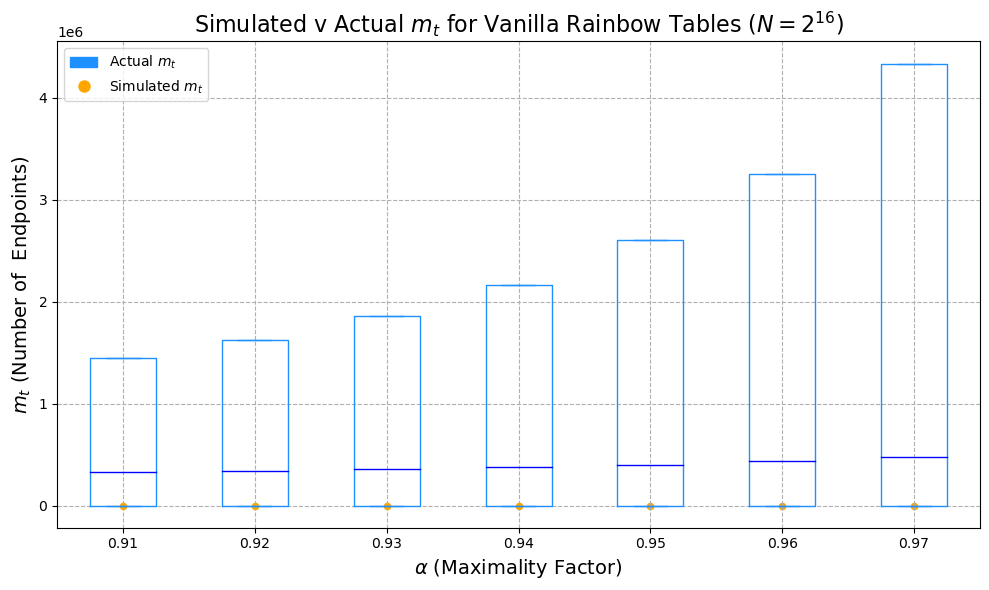

In [239]:
# Make into a graph

data = pd.read_csv("vanilla_N_16_different_alpha_0.91_0.97_results.csv")
# x_indicies = range(len(alphas))
alphas = list([x / 100 for x in range(91, 98)])
x_indicies = range(len(alphas))

plt.figure(figsize=(10,6))

# plot for each alpha, a box plot using the trials
# convert samples from dataframe to a single list for boxplot
plt.boxplot([data.loc[data['alpha'] == alpha, data.columns[2:]].values.flatten() for alpha in alphas], 
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='dodgerblue'),
            medianprops=dict(color='blue'),
            whiskerprops=dict(color='dodgerblue'),
            capprops=dict(color='dodgerblue'),
            flierprops=dict(markerfacecolor='dodgerblue', marker='o', markersize=5, markeredgecolor='none'))

# plot simulated_mt as scatter
plt.scatter(x_indicies, data['optimiser_mt'], color='orange', label='Simulated $m_t$ ', s=20)

plt.xlabel('$\\alpha$ (Maximality Factor)', fontsize=14)
plt.ylabel('$m_t$ (Number of  Endpoints)', fontsize=14)
plt.title('Simulated v Actual $m_t$ for Vanilla Rainbow Tables ($N=2^{16}$)', fontsize=16)
plt.grid(linestyle="--")
# spread alphas evenly on x-axis
plt.xticks(x_indicies, alphas)
# add box plot legend manually
box_legend = mpatches.Patch(color="dodgerblue", label="Actual $m_t$")
plt.legend(handles=[box_legend, plt.Line2D([0], [0], marker='o', color='w', label='Simulated $m_t$', markerfacecolor='orange', markersize=10)])
plt.tight_layout()
plt.show()